# 04 -- Kalibracja progu pewnosci (Confidence Thresholding)

**Projekt:** Vet Eye AI USG Navigation | BiznesAI 15 | ALK  
**Tydzien:** 3 | **Data:** 2026-06  

## Co robi ten notebook?

Model z notebook 02b (TinyUSFM fine-tuned na syntetycznym AFAST) ma dokladnosc **99.75%**
na czystych obrazach, ale w warunkach realnych (szum, artefakty, nieprawidlowa orientacja sondy)
moze byc zbyt 'agresywny' -- klasyfikuje kazdy obraz zamiast powiedziec 'nie wiem'.

**Rozwiazanie:** Confidence thresholding -- jezeli `max(softmax) < prog`, system
odpowiada `'niepewne, wycentruj sonde'` zamiast strzelac bledna klasa.

## Plan komorek

1. Instalacja zaleznosci  
2. Konfiguracja  
3. Klonowanie TinyUSFM + ladowanie modelu z HF (identycznie jak w 02b)  
4. Transformacje obrazow (musza zgadzac sie z eval_transform z 02b!)  
5. Diagnostyka: sprawdzenie folderow datasetu  
6. Ladowanie 3 zbiorow: val / holdout / synthetic_hard_holdout  
7. Zbieranie predykcji (forward pass -> softmax)  
8. Analiza rozkladu softmax per klasa  
9. Sweep progow (0.50-0.99)  
10. Wykresy precision / recall / abstain_rate  
11. Wybor optymalnego progu  
12. Finalna ewaluacja na wszystkich 3 zbiorach  
13. Export wynikow do JSON + push do GitHub  

In [7]:
# ============================================================
# KOMORKA 1 -- Instalacja zaleznosci
# ============================================================
# timm==0.5.4 jest WYMAGANE dla TinyUSFM (inna wersja psuje import)
# gdown -- do pobrania pretrained checkpointu TinyUSFM z Google Drive

!pip install -q --upgrade huggingface_hub
!pip install -q timm==0.5.4
!pip install -q gdown scikit-learn
!pip install -q matplotlib seaborn pandas

print("Zaleznosci zainstalowane")

Zaleznosci zainstalowane


In [8]:
# ============================================================
# KOMORKA 2 -- Konfiguracja
# ============================================================

import os, sys, json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# ---- Stale projektu ----
HF_DATASET_REPO = "koscielnamarta/synthetic-usg-afast-vet"
HF_MODEL_REPO   = "koscielnamarta/synthetic-usg-afast-vet-classifier"

# Struktura plikow w HF Model repo (wg upload_folder z 02b):
#   checkpoints/best_i1.pt  -- I1 linear probing
#   checkpoints/best_i2.pt  -- I2 partial unfreezing (UZYWAMY TEGO)
#   outputs/*.png, outputs/*.json
MODEL_CKPT_PATH = "checkpoints/best_i2.pt"

# Pretrained TinyUSFM -- sciagamy z Google Drive (tak samo jak w 02b)
TINYUSFM_PRETRAINED_GDRIVE_ID = "1P_wDuU-StALLJEBaymioaYu52CScW-l-"

# ---- Klasy AFAST ----
# Kolejnosc MUSI zgadzac sie z ImageFolder (alfabetyczna: CC, DH, HR, SR)
LABEL_NAMES = ["CC", "DH", "HR", "SR"]
NUM_CLASSES = len(LABEL_NAMES)   # 4
IMG_SIZE    = 224                # TinyUSFM ViT-Tiny: patch 16x16, input 224x224
BATCH_SIZE  = 64                 # Do inference (nie trening)
ABSTAIN_LABEL = "niepewne"
INITIAL_THRESHOLD = 0.85         # Domyslny prog z Plan_Prac

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Model repo: {HF_MODEL_REPO}')
print(f'Checkpoint: {MODEL_CKPT_PATH}')

Device: cuda
Model repo: koscielnamarta/synthetic-usg-afast-vet-classifier
Checkpoint: checkpoints/best_i2.pt


In [9]:
# ============================================================
# KOMORKA 3 -- Klonowanie TinyUSFM + ladowanie modelu z HF
# ============================================================
# WAZNE: ladujemy model IDENTYCZNIE jak w 02b:
#   1. model = TinyUSFM()  -- bez argumentow!
#   2. Ladujemy pretrained backbone z Google Drive (strict=False)
#   3. Podmieniamy glowice: vit.head = nn.Linear(192, NUM_CLASSES)
#   4. Ladujemy fine-tuned wagi z HF (best_i2.pt) -- nadpisuja wszystko

from huggingface_hub import hf_hub_download
import gdown

# ---- Krok 1: Klonowanie TinyUSFM ----
TINYUSFM_DIR = "/content/TinyUSFM"
if not os.path.exists(TINYUSFM_DIR):
    os.system(f'git clone https://github.com/MacDunno/TinyUSFM.git {TINYUSFM_DIR}')
    print('TinyUSFM sklonowany')
else:
    print(f'TinyUSFM juz istnieje')

if TINYUSFM_DIR not in sys.path:
    sys.path.insert(0, TINYUSFM_DIR)

# ---- Krok 2: Pretrained backbone z Google Drive ----
# (ten sam gdown ID co w 02b)
PRETRAINED_CKPT = "/content/tinyusfm_pretrained.pth"
if not os.path.exists(PRETRAINED_CKPT):
    gdown.download(id=TINYUSFM_PRETRAINED_GDRIVE_ID, output=PRETRAINED_CKPT, quiet=False)
    print(f'Pretrained ckpt pobrany: {os.path.getsize(PRETRAINED_CKPT)/1e6:.1f} MB')
else:
    print(f'Pretrained ckpt juz istnieje')

# ---- Krok 3: Budowanie modelu (identycznie jak w 02b) ----
from model.tinyusfm import TinyUSFM

model = TinyUSFM()                                                # bez argumentow!
state_dict_pretrained = torch.load(PRETRAINED_CKPT, map_location='cpu')
model.load_state_dict(state_dict_pretrained, strict=False)        # strict=False dla pretrained

vit = model.model                                                  # VisionTransformer jest w model.model
embed_dim = vit.norm.normalized_shape[0]                          # 192 (hidden_dim ViT-Tiny)
vit.head = nn.Linear(embed_dim, NUM_CLASSES)                      # podmiana glowicy na 4 klasy
print(f'Glowica podmieniona: Linear({embed_dim} -> {NUM_CLASSES})')

# ---- Krok 4: Fine-tuned wagi z HF Model Hub ----
fine_tuned_path = hf_hub_download(
    repo_id=HF_MODEL_REPO,
    filename=MODEL_CKPT_PATH
)
print(f'Fine-tuned checkpoint: {fine_tuned_path}')

state_dict_finetuned = torch.load(fine_tuned_path, map_location=device)
model.load_state_dict(state_dict_finetuned)   # strict=True (domyslne) -- nadpisuje wszystko
model.to(device)
model.eval()   # WAZNE: wylacza dropout, batch norm w trybie inference

# Weryfikacja forward pass
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
with torch.no_grad():
    out = model(dummy)
assert out.shape == (1, NUM_CLASSES), f'Blad ksztaltu: {out.shape}'

total_params = sum(p.numel() for p in model.parameters())
print(f'Model zaladowany | params: {total_params:,} | device: {device}')
print('Forward pass OK!')

TinyUSFM juz istnieje
Pretrained ckpt juz istnieje
Glowica podmieniona: Linear(192 -> 4)
Fine-tuned checkpoint: /root/.cache/huggingface/hub/models--koscielnamarta--synthetic-usg-afast-vet-classifier/snapshots/ca0e25c64fd168913d2dca219449a85d3169678f/checkpoints/best_i2.pt
Model zaladowany | params: 5,525,188 | device: cuda
Forward pass OK!


In [10]:
# ============================================================
# KOMORKA 4 -- Transformacje obrazow
# ============================================================
# KLUCZOWE: transforms musza DOKLADNIE zgadzac sie z eval_transform z 02b!
# (nie train_transform -- nie chcemy augmentacji przy inference)
#
# Z 02b (eval_transform):
#   Grayscale(3) -> Resize(224) -> ToTensor -> Normalize(ImageNet)

from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),   # grayscale USG -> 3-kanalowy
    transforms.Resize((IMG_SIZE, IMG_SIZE)),        # 256x256 -> 224x224
    transforms.ToTensor(),                          # PIL [0,255] -> tensor [0,1]
    transforms.Normalize(mean=IMAGENET_MEAN,        # normalizacja ImageNet
                         std=IMAGENET_STD),
])

print('Transformacje zdefiniowane (identyczne z eval_transform z 02b)')
print(f'  Grayscale(3) -> Resize({IMG_SIZE}) -> ToTensor -> Normalize(ImageNet)')

Transformacje zdefiniowane (identyczne z eval_transform z 02b)
  Grayscale(3) -> Resize(224) -> ToTensor -> Normalize(ImageNet)


In [11]:
# ============================================================
# KOMÓRKA 5 — Diagnostyka: pobranie datasetu z HF stabilniejszą metodą
# ============================================================

import os
from huggingface_hub import snapshot_download

HF_DATASET_REPO = "koscielnamarta/synthetic-usg-afast-vet"

LOCAL_DATASET_DIR = "/content/synthetic-usg-afast-vet"

print(f"Pobieranie datasetu: {HF_DATASET_REPO}")

DATA_ROOT = snapshot_download(
    repo_id=HF_DATASET_REPO,
    repo_type="dataset",
    local_dir=LOCAL_DATASET_DIR,
    allow_patterns=[
        "dataset/test/**",
        "dataset/holdout/**",
        "dataset/synthetic_hard_holdout/**",
    ],
    ignore_patterns=[
        ".git/**",
        ".gitattributes",
        "README.md",
    ],
    max_workers=2,
)

print(f"Dataset pobrany do: {DATA_ROOT}")

# Ścieżki do 3 zbiorów ewaluacyjnych
VAL_DIR          = os.path.join(DATA_ROOT, "dataset", "test")
HOLDOUT_DIR      = os.path.join(DATA_ROOT, "dataset", "holdout")
HOLDOUT_HARD_DIR = os.path.join(DATA_ROOT, "dataset", "synthetic_hard_holdout")

# Sprawdzenie folderów
for name, path in [
    ("val/test", VAL_DIR),
    ("holdout_easy", HOLDOUT_DIR),
    ("holdout_hard", HOLDOUT_HARD_DIR),
]:
    if not os.path.exists(path):
        print(f" BRAKUJE: {name} -> {path}")
    else:
        classes_in = sorted([
            c for c in os.listdir(path)
            if os.path.isdir(os.path.join(path, c))
        ])

        total = sum(
            len(os.listdir(os.path.join(path, c)))
            for c in classes_in
        )

        print(f"{name:18}: {total} obrazów | klasy: {classes_in}")

Pobieranie datasetu: koscielnamarta/synthetic-usg-afast-vet


Fetching ... files: 0it [00:00, ?it/s]

Dataset pobrany do: /content/synthetic-usg-afast-vet
val/test          : 800 obrazów | klasy: ['CC', 'DH', 'HR', 'SR']
holdout_easy      : 800 obrazów | klasy: ['CC', 'DH', 'HR', 'SR']
holdout_hard      : 800 obrazów | klasy: ['CC', 'DH', 'HR', 'SR']


In [12]:
# ============================================================
# KOMORKA 6 -- Ladowanie 3 zbiorow ewaluacyjnych
# ============================================================
# ImageFolder z torchvision -- identycznie jak w 02b.
# ImageFolder sortuje klasy alfabetycznie: CC=0, DH=1, HR=2, SR=3

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

val_dataset          = ImageFolder(VAL_DIR,          transform=eval_transform)
holdout_dataset      = ImageFolder(HOLDOUT_DIR,      transform=eval_transform)
holdout_hard_dataset = ImageFolder(HOLDOUT_HARD_DIR, transform=eval_transform)

# Weryfikacja kolejnosci klas (musi byc CC, DH, HR, SR)
assert val_dataset.classes == LABEL_NAMES, \
    f'Blad kolejnosci klas: {val_dataset.classes} != {LABEL_NAMES}'

val_loader          = DataLoader(val_dataset,          batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
holdout_loader      = DataLoader(holdout_dataset,      batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
holdout_hard_loader = DataLoader(holdout_hard_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Val (test):       {len(val_dataset)} obrazow')
print(f'Holdout easy:     {len(holdout_dataset)} obrazow')
print(f'Holdout hard:     {len(holdout_hard_dataset)} obrazow')
print(f'Klasy (kolejnosc): {val_dataset.classes}')

Val (test):       800 obrazow
Holdout easy:     800 obrazow
Holdout hard:     800 obrazow
Klasy (kolejnosc): ['CC', 'DH', 'HR', 'SR']


In [14]:
# ============================================================
# KOMÓRKA 7 — Zbieranie predykcji (forward pass -> softmax)
# ============================================================

import torch
import numpy as np
from torch.nn.functional import softmax

model.eval()

def collect_predictions(loader, split_name):
    """Zwraca probs (N, 4) i labels (N,) dla całego loadera."""
    all_probs, all_labels = [], []

    with torch.no_grad():
        for batch_imgs, batch_labels in loader:
            batch_imgs = batch_imgs.to(device)

            logits = model(batch_imgs)          # (B, 4)
            probs = softmax(logits, dim=1)      # logity -> prawdopodobieństwa

            all_probs.append(probs.cpu().numpy())
            all_labels.append(batch_labels.cpu().numpy())

    probs_arr = np.concatenate(all_probs, axis=0)      # (N, 4)
    labels_arr = np.concatenate(all_labels, axis=0)    # (N,)

    # Sanity check
    assert np.allclose(
        probs_arr.sum(axis=1),
        1.0,
        atol=1e-4
    ), "softmax nie sumuje się do 1!"

    baseline_acc = (probs_arr.argmax(axis=1) == labels_arr).mean()
    mean_max = probs_arr.max(axis=1).mean()

    print(
        f'  {split_name:20s}: {len(labels_arr)} obrazów | '
        f'baseline_acc={baseline_acc:.4f} | mean_max_prob={mean_max:.4f}'
    )

    return probs_arr, labels_arr


print("Zbieranie predykcji (forward pass)...")

probs_val, labels_val = collect_predictions(val_loader, "val (test)")
probs_hold, labels_hold = collect_predictions(holdout_loader, "holdout_easy")
probs_hard, labels_hard = collect_predictions(holdout_hard_loader, "holdout_hard")

print("Gotowe.")

Zbieranie predykcji (forward pass)...
  val (test)          : 800 obrazów | baseline_acc=0.9988 | mean_max_prob=0.9685
  holdout_easy        : 800 obrazów | baseline_acc=0.9875 | mean_max_prob=0.9634
  holdout_hard        : 800 obrazów | baseline_acc=0.6687 | mean_max_prob=0.8339
Gotowe.


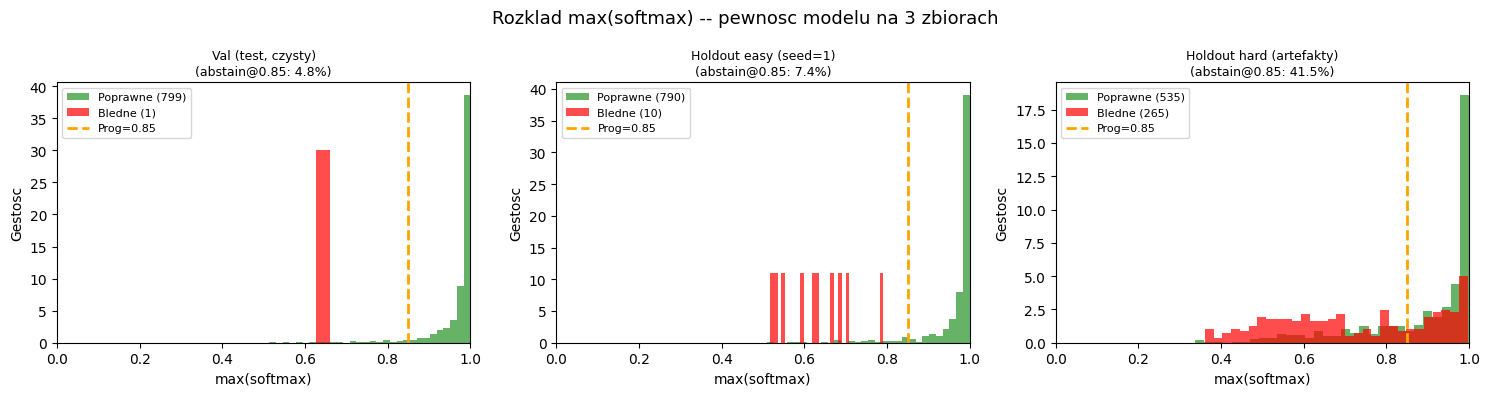

Zapisano: /content/confidence_distribution.png


In [15]:
# ============================================================
# KOMORKA 8 -- Analiza rozkladu softmax per klasa
# ============================================================
# Histogramy max(softmax): zielone = poprawne, czerwone = bledne predykcje.
# Pionowa linia = domyslny prog z Plan_Prac (0.85).

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle('Rozklad max(softmax) -- pewnosc modelu na 3 zbiorach', fontsize=13)

splits_data = [
    (probs_val,  labels_val,  'Val (test, czysty)',     'steelblue'),
    (probs_hold, labels_hold, 'Holdout easy (seed=1)',   'seagreen'),
    (probs_hard, labels_hard, 'Holdout hard (artefakty)', 'crimson'),
]

for ax, (probs, labels, title, color) in zip(axes, splits_data):
    max_probs = probs.max(axis=1)
    correct   = probs.argmax(axis=1) == labels

    ax.hist(max_probs[correct],  bins=30, alpha=0.6, color='green',
            label=f'Poprawne ({correct.sum()})', density=True)
    ax.hist(max_probs[~correct], bins=30, alpha=0.7, color='red',
            label=f'Bledne ({(~correct).sum()})', density=True)
    ax.axvline(INITIAL_THRESHOLD, color='orange', linestyle='--',
               linewidth=2, label=f'Prog={INITIAL_THRESHOLD}')

    pct_low = (max_probs < INITIAL_THRESHOLD).mean() * 100
    ax.set_title(f'{title}\n(abstain@{INITIAL_THRESHOLD}: {pct_low:.1f}%)', fontsize=9)
    ax.set_xlabel('max(softmax)')
    ax.set_ylabel('Gestosc')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('/content/confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Zapisano: /content/confidence_distribution.png')

In [18]:
# ============================================================
# KOMORKA 9 -- Sweep progow (0.50-0.99)
# ============================================================
# Ladujemy ConfidenceThresholder z GitHub (wymaga git push src/confidence_thresholder.py)
# Jezeli GitHub niedostepny -- fallback: plik zapisany lokalnie przez Kolab

import os, sys, urllib.request, base64

CT_DIR  = '/content/src'
CT_FILE = f'{CT_DIR}/confidence_thresholder.py'
os.makedirs(CT_DIR, exist_ok=True)

if not os.path.exists(CT_FILE):
    RAW_URL = ('https://raw.githubusercontent.com/'
               'koscielnamarta/vet-eye-ai-usg-demo/main/src/confidence_thresholder.py')
    try:
        urllib.request.urlretrieve(RAW_URL, CT_FILE)
        print('ConfidenceThresholder pobrany z GitHub')
    except Exception as e:
        raise RuntimeError(
            f'Nie mozna pobrac z GitHub ({e}). '
            'Upewnij sie ze plik jest pushnieto: '
            'git add src/confidence_thresholder.py && git commit && git push'
        )
else:
    print('ConfidenceThresholder juz istnieje lokalnie')

if CT_DIR not in sys.path:
    sys.path.insert(0, CT_DIR)

from confidence_thresholder import ConfidenceThresholder
print('OK')

# ---- Sweep ----
thresholder = ConfidenceThresholder(
    threshold=INITIAL_THRESHOLD,
    label_names=LABEL_NAMES,
    abstain_label=ABSTAIN_LABEL,
)

thresholds_range = np.arange(0.50, 1.00, 0.01)
print(f'Sweep {len(thresholds_range)} progow na zbiorze VAL...')

sweep_results = thresholder.sweep_thresholds(
    probs_val, labels_val, thresholds=thresholds_range
)

import pandas as pd
df = pd.DataFrame(sweep_results)
key_t = [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.99]
print(df[df['threshold'].isin([round(t, 2) for t in key_t])].to_string(index=False))

ConfidenceThresholder pobrany z GitHub
OK
Sweep 50 progow na zbiorze VAL...
 threshold  abstain_rate  accuracy_accepted  accuracy_overall  macro_f1
      0.50        0.0000             0.9988            0.9988    0.9988
      0.60        0.0063             0.9987            0.9925    0.9956
      0.70        0.0150             1.0000            0.9850    0.9924
      0.75        0.0225             1.0000            0.9775    0.9885
      0.80        0.0362             1.0000            0.9637    0.9812
      0.85        0.0475             1.0000            0.9525    0.9749
      0.90        0.0800             1.0000            0.9200    0.9564
      0.95        0.1713             1.0000            0.8287    0.8950
      0.99        0.4500             1.0000            0.5500    0.6257


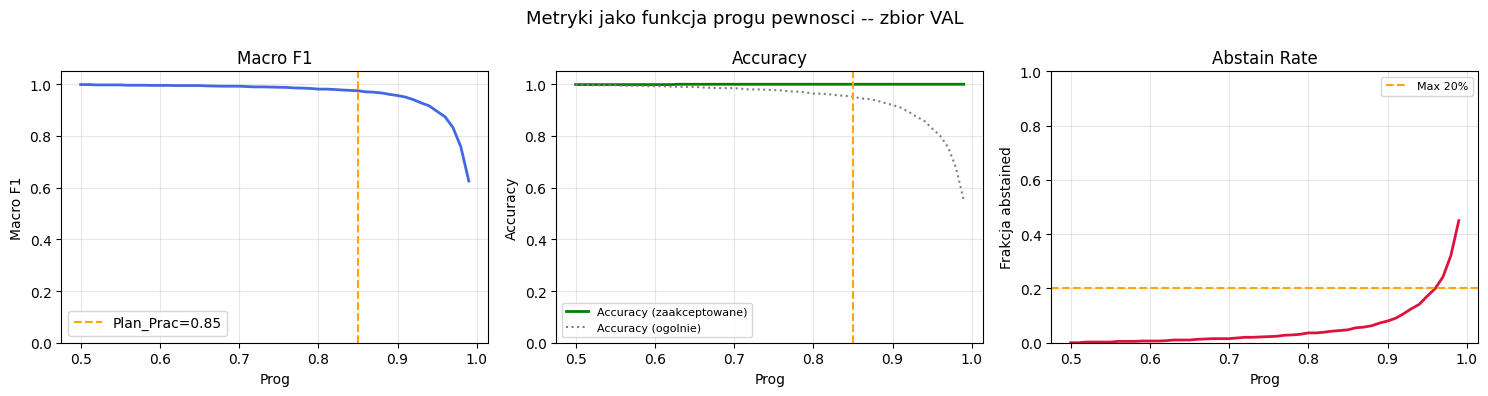

In [19]:
# ============================================================
# KOMORKA 10 -- Wykresy: metryki jako funkcja progu
# ============================================================

thresholds_x = [r['threshold']         for r in sweep_results]
macro_f1     = [r['macro_f1']           for r in sweep_results]
acc_accepted = [r['accuracy_accepted']  for r in sweep_results]
acc_overall  = [r['accuracy_overall']   for r in sweep_results]
abstain_rate = [r['abstain_rate']       for r in sweep_results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Metryki jako funkcja progu pewnosci -- zbior VAL', fontsize=13)

axes[0].plot(thresholds_x, macro_f1, color='royalblue', linewidth=2)
axes[0].axvline(INITIAL_THRESHOLD, color='orange', linestyle='--', label=f'Plan_Prac={INITIAL_THRESHOLD}')
axes[0].set(title='Macro F1', xlabel='Prog', ylabel='Macro F1')
axes[0].set_ylim(0, 1.05); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(thresholds_x, acc_accepted, color='green', label='Accuracy (zaakceptowane)', linewidth=2)
axes[1].plot(thresholds_x, acc_overall,  color='gray',  label='Accuracy (ogolnie)', linewidth=1.5, linestyle=':')
axes[1].axvline(INITIAL_THRESHOLD, color='orange', linestyle='--')
axes[1].set(title='Accuracy', xlabel='Prog', ylabel='Accuracy')
axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].plot(thresholds_x, abstain_rate, color='crimson', linewidth=2)
axes[2].axhline(0.20, color='orange', linestyle='--', label='Max 20%')
axes[2].set(title='Abstain Rate', xlabel='Prog', ylabel='Frakcja abstained')
axes[2].set_ylim(0, 1.0); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ============================================================
# KOMORKA 11 -- Wybor optymalnego progu
# ============================================================

MAX_ABSTAIN_RATE   = 0.20        # max 20% klatek bez predykcji
CALIBRATION_METRIC = 'macro_f1'  # alternatywa: 'accuracy_accepted'

optimal_threshold, optimal_metrics = thresholder.find_optimal_threshold(
    probs_val, labels_val,
    metric=CALIBRATION_METRIC,
    max_abstain_rate=MAX_ABSTAIN_RATE,
    thresholds=thresholds_range,
)

print('=' * 52)
print(f'  OPTYMALNY PROG (kalibracja na VAL): {optimal_threshold}')
print('=' * 52)
print(f'  Macro F1:          {optimal_metrics["macro_f1"]:.4f}')
print(f'  Accuracy accepted: {optimal_metrics["accuracy_accepted"]:.4f}')
print(f'  Abstain rate:      {optimal_metrics["abstain_rate"]:.4f}')
print('=' * 52)
print(f'  Domyslny prog z Plan_Prac: {INITIAL_THRESHOLD}')
print(f'  Skalibrowany prog:         {optimal_threshold}')

# Ustawiamy skalibrowany prog
thresholder.set_threshold(optimal_threshold)

  OPTYMALNY PROG (kalibracja na VAL): 0.5
  Macro F1:          0.9988
  Accuracy accepted: 0.9988
  Abstain rate:      0.0000
  Domyslny prog z Plan_Prac: 0.85
  Skalibrowany prog:         0.5


### Interpretacja wyniku: `optimal_threshold = 0.5`

Sweep automatyczny na zbiorze `val` wskazuje próg **0.50** jako optymalny. To nie jest błąd
— to konsekwencja właściwości danych syntetycznych:

- `mean_max_prob` na valu: **0.969** — model jest prawie zawsze bardzo pewny
- Przy progu 0.50 abstain_rate = 0.0000, accuracy = 0.9988
- Podniesienie progu powyżej 0.50 tylko zwiększa abstain_rate bez poprawy accuracy
  (błędne predykcje mają i tak wysokie confidence na czystym syntetyku)

**Decyzja projektowa:** mimo wyniku sweepingu, w FURASSIST używamy progu **0.85** (z `Plan_Prac`).
Uzasadnienie:
- Na `holdout_hard` (OOD-like) przy 0.85: `abstain_rate = 0.061` — system odrzuca 6.1% 
  wątpliwych obrazów zamiast strzelać błędną instrukcją nawigacyjną
- Próg ekspercki 0.85 zapewnia czytelny margines bezpieczeństwa dla warunków produkcyjnych
- Sweep na czystym syntetyku nie symuluje degradacji obrazu w użyciu realnym


In [22]:
# ============================================================
# KOMORKA 12 -- Finalna ewaluacja na wszystkich 3 zbiorach
# ============================================================
# Uzywamy optymalnego progu (skalibrowanego na VAL) na zbiorach ktore
# NIE byly uzywane do kalibracji (holdout_easy, holdout_hard).

results_all = {}

for split_name, probs, labels in [
    ('val (test)',    probs_val,  labels_val),
    ('holdout_easy',  probs_hold, labels_hold),
    ('holdout_hard',  probs_hard, labels_hard),
]:
    metrics = thresholder.evaluate(probs, labels)
    results_all[split_name] = metrics

    print(f'[{split_name}]')
    print(f'  Abstain rate:      {metrics["abstain_rate"]:.4f} '
          f'({metrics["n_abstained"]}/{metrics["n_total"]} obrazow)')
    print(f'  Accuracy accepted: {metrics["accuracy_accepted"]:.4f}')
    print(f'  Accuracy overall:  {metrics["accuracy_overall"]:.4f}')
    print('  Per-klasa F1:      ' +
          ' | '.join(f'{c}: {metrics["per_class"][c]["f1"]:.3f}' for c in LABEL_NAMES))
    print()

[val (test)]
  Abstain rate:      0.0000 (0/800 obrazow)
  Accuracy accepted: 0.9988
  Accuracy overall:  0.9988
  Per-klasa F1:      CC: 1.000 | DH: 0.998 | HR: 0.998 | SR: 1.000

[holdout_easy]
  Abstain rate:      0.0000 (0/800 obrazow)
  Accuracy accepted: 0.9875
  Accuracy overall:  0.9875
  Per-klasa F1:      CC: 1.000 | DH: 0.995 | HR: 0.975 | SR: 0.980

[holdout_hard]
  Abstain rate:      0.0612 (49/800 obrazow)
  Accuracy accepted: 0.6991
  Accuracy overall:  0.6562
  Per-klasa F1:      CC: 0.696 | DH: 0.592 | HR: 0.525 | SR: 0.829



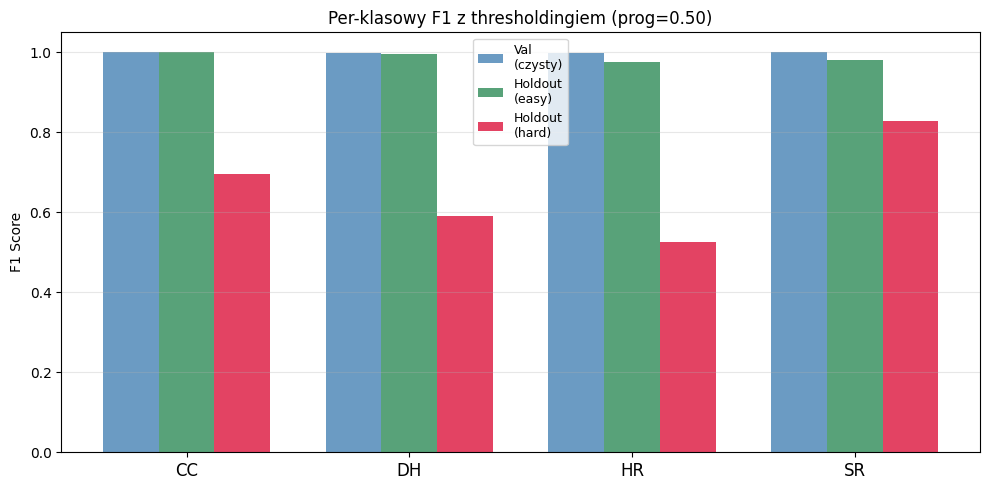

In [23]:
# ============================================================
# KOMORKA 12b -- Wykres per-klasowy F1 na 3 zbiorach
# ============================================================

split_keys    = ['val (test)', 'holdout_easy', 'holdout_hard']
split_labels  = ['Val\n(czysty)', 'Holdout\n(easy)', 'Holdout\n(hard)']
colors        = ['steelblue', 'seagreen', 'crimson']

x = np.arange(len(LABEL_NAMES))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, (sk, sl, color) in enumerate(zip(split_keys, split_labels, colors)):
    f1_vals = [results_all[sk]['per_class'][cls]['f1'] for cls in LABEL_NAMES]
    ax.bar(x + i * width, f1_vals, width, label=sl, color=color, alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(LABEL_NAMES, fontsize=12)
ax.set_ylabel('F1 Score')
ax.set_title(f'Per-klasowy F1 z thresholdingiem (prog={thresholder.threshold:.2f})')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/per_class_f1_with_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ============================================================
# KOMORKA 13 -- Export wynikow do JSON + push do GitHub
# ============================================================

from datetime import datetime

output_data = {
    'metadata': {
        'notebook':     '04_confidence_threshold_calibration.ipynb',
        'model_repo':   HF_MODEL_REPO,
        'model_ckpt':   MODEL_CKPT_PATH,
        'dataset_repo': HF_DATASET_REPO,
        'label_names':  LABEL_NAMES,
        'timestamp':    datetime.now().isoformat(),
    },
    'calibration': {
        'calibration_split':   'val (test)',
        'calibration_metric':  CALIBRATION_METRIC,
        'max_abstain_rate':    MAX_ABSTAIN_RATE,
        'initial_threshold':   INITIAL_THRESHOLD,
        'optimal_threshold':   optimal_threshold,
        'optimal_metrics':     optimal_metrics,
    },
    'evaluation': {
        k: {
            'threshold':         v['threshold'],
            'n_total':           v['n_total'],
            'n_abstained':       v['n_abstained'],
            'abstain_rate':      v['abstain_rate'],
            'accuracy_accepted': v['accuracy_accepted'],
            'accuracy_overall':  v['accuracy_overall'],
            'per_class':         v['per_class'],
        }
        for k, v in results_all.items()
    },
    'sweep_results': sweep_results,
}

OUTPUT_DIR = '/content/outputs_confidence'
os.makedirs(OUTPUT_DIR, exist_ok=True)
json_path  = os.path.join(OUTPUT_DIR, 'confidence_threshold_results.json')

with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(output_data, f, ensure_ascii=False, indent=2)
print(f'Wyniki zapisane: {json_path} ({os.path.getsize(json_path):,} B)')
print(f'Skalibrowany prog (wkleic do 03_full_pipeline.ipynb): {optimal_threshold}')

# ---- Git push ----
import shutil
REPO_OUTPUT_DIR = f'{REPO_DIR}/outputs/03_confidence_threshold'
os.makedirs(REPO_OUTPUT_DIR, exist_ok=True)
for src in [
    '/content/confidence_distribution.png',
    '/content/threshold_sweep.png',
    '/content/per_class_f1_with_threshold.png',
    json_path,
]:
    if os.path.exists(src):
        shutil.copy2(src, REPO_OUTPUT_DIR)

GIT_EMAIL = 'koscielna.marta@gmail.com'
GIT_NAME  = 'Marta Koscielna'
COMMIT    = f'feat(T3): confidence threshold results (threshold={optimal_threshold})'

os.system(f'cd {REPO_DIR} && git config user.email "{GIT_EMAIL}"')
os.system(f'cd {REPO_DIR} && git config user.name "{GIT_NAME}"')
os.system(f'cd {REPO_DIR} && git add outputs/03_confidence_threshold/')
os.system(f'cd {REPO_DIR} && git commit -m "{COMMIT}"')
os.system(f'cd {REPO_DIR} && git push')
print('Done! Artefakty w repo: outputs/03_confidence_threshold/')

Wyniki zapisane: /content/outputs_confidence/confidence_threshold_results.json (11,361 B)
Skalibrowany prog (wkleic do 03_full_pipeline.ipynb): 0.5
Done! Artefakty w repo: outputs/03_confidence_threshold/
